# Driver Drowsiness System

##Requirements:
1. Open the Secrets (Key Icon) tab in the sidebar, add your MongoDB link with the name MONGO_URI, and turn on notebook access.

##Cells Number:
1. Install required package
2. Import libraries
3. Download dataset
4. Batch Size
5. Load the datasets
6. Build the CNN Model
7. Compile the Model
8. Train the Model
9. Evaluate on the Test Set
10. Extract metrics
11. Prediction for confusion matrix
12. plot performance dashboard
13. Connect to database
14. Extract text and summary
15. Visual summary
16. Save to database
17. Save model

In [2]:
#1. Install required package
!python -m pip install "pymongo[srv]==3.12"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.6/818.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.4/188.4 kB 15.2 MB/s eta 0:00:00
  Created wheel for pymongo: filename=pymongo-3.12.0-cp312-cp312-linux_x86_64.whl size=512719 sha256=b60cf6f930c3e2f3317279705e6719c127cf3f184169a990740f260f8e15b08d
  Stored in directory: /root/.cache/pip/wheels/4e/49/39/293a3914a095e62eeefc25b88f9f5ace620fc19d9b1883762b
Successfully built pymongo


In [16]:
# 2. Import libraries
import os
import io
import kagglehub
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import gc
import base64
from datetime import datetime, timezone
from google.colab import userdata
from pymongo import MongoClient

In [4]:
# 3. Download dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("sehriyarmemmedli/open-closed-eyes-dataset")
print("Path to dataset files:", path)

train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'val')
test_dir = os.path.join(path, 'test')

100%|██████████| 1.44G/1.44G [00:38<00:00, 40.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sehriyarmemmedli/open-closed-eyes-dataset/versions/3


In [5]:
# 4. Batch Size
BATCH_SIZE = 16
IMG_SIZE = (90, 90)

In [6]:
# 5. Load the datasets
print("\nLoading datasets into TensorFlow...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='binary'
)

# 🚨 FIX: We removed .cache() here to prevent RAM crashes!
# We keep .prefetch() because it safely buffers data on the CPU while the GPU trains.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Loading datasets into TensorFlow...
Found 139804 files belonging to 2 classes.
Found 27961 files belonging to 2 classes.
Found 6991 files belonging to 2 classes.


In [7]:
# 6. Build the CNN Model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(90, 90, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# 7. Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 90, 90, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 88, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 42, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,609 (5.42 MB)

 Trainable params: 1,420,609 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 8. Train the Model
EPOCHS = 10
print("\nStarting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Starting training...
Epoch 1/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 98s 11ms/step - accuracy: 0.9585 - loss: 0.1152 - val_accuracy: 0.9795 - val_loss: 0.0568
Epoch 2/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 89s 10ms/step - accuracy: 0.9810 - loss: 0.0540 - val_accuracy: 0.9849 - val_loss: 0.0430
Epoch 3/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 148s 11ms/step - accuracy: 0.9850 - loss: 0.0430 - val_accuracy: 0.9849 - val_loss: 0.0416
Epoch 4/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.9875 - loss: 0.0357 - val_accuracy: 0.9860 - val_loss: 0.0431
Epoch 5/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - accuracy: 0.9887 - loss: 0.0315 - val_accuracy: 0.9866 - val_loss: 0.0446
Epoch 6/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 95s 11ms/step - accuracy: 0.9898 - loss: 0.0289 - val_accuracy: 0.9889 - val_loss: 0.0368
Epoch 7/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 133s 10ms/step - accuracy: 0.9906 - loss: 0.0264 - val_accuracy: 0.9894 - val_loss: 0.0388
Epoch 8/10
8738/8738 ━━━━━━━━━━━━━━━━━━━━ 145s 10ms/

In [10]:
# 9. Evaluate on the Test Set
print("\nEvaluating on Test data...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


Evaluating on Test data...
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9906 - loss: 0.0374

Final Test Accuracy: 99.06%


In [11]:
# 10. Extract metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

In [12]:
# 11. Prediction for confusion matrix
print("🧠 Extracting true labels and calculating test set predictions...")
# Unbatch and extract true test labels
y_true = np.concatenate([y for x, y in test_ds], axis=0).flatten()

# Get model prediction probabilities
y_pred_probs = model.predict(test_ds, verbose=0).flatten()
# Convert probabilities to binary choices (0 or 1) based on a 0.5 threshold
y_pred = (y_pred_probs >= 0.5).astype(int)

# Class names based on standard folder structure alphabetization (Closed=0, Open=1)
class_names = ['Closed Eyes', 'Open Eyes']

🧠 Extracting true labels and calculating test set predictions...


/tmp/ipykernel_959/1866994029.py:51: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_959/1866994029.py:54: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  plt.savefig('eye_detector_visual_summary.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


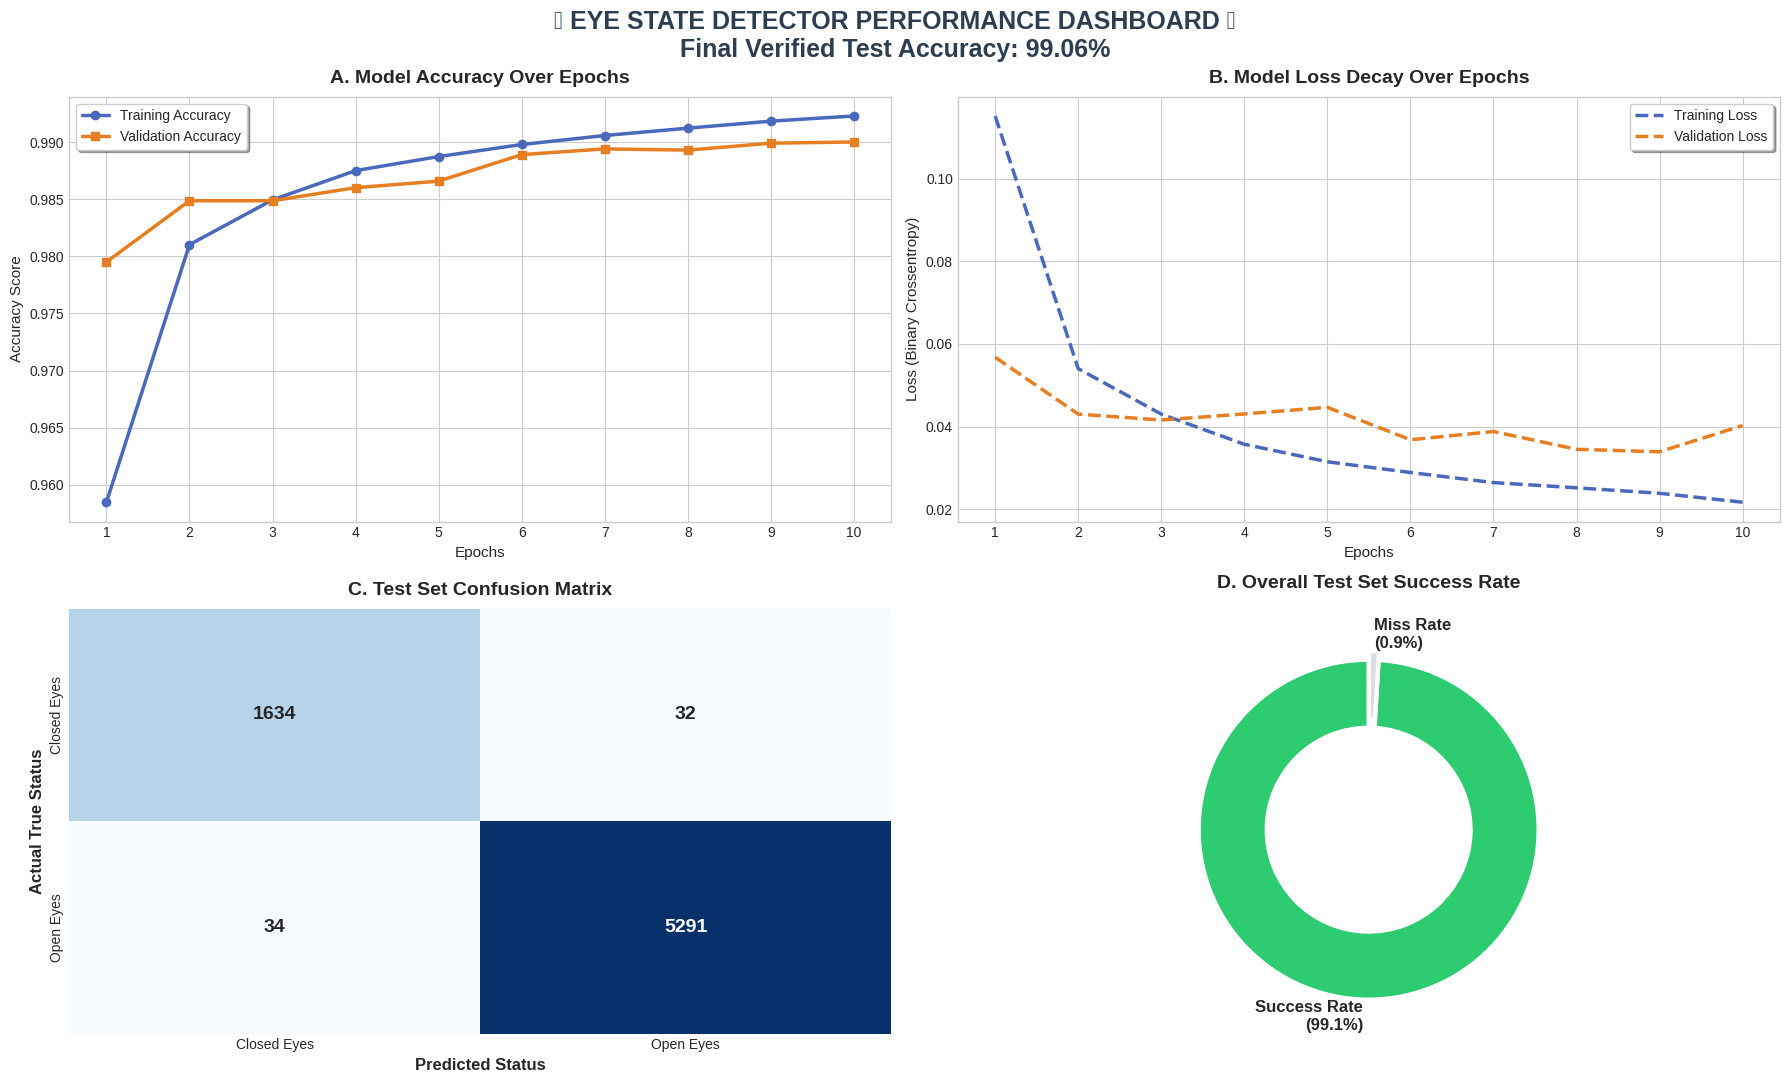


📝 Detailed Textual Classification Summary:
              precision    recall  f1-score   support

 Closed Eyes       0.98      0.98      0.98      1666
   Open Eyes       0.99      0.99      0.99      5325

    accuracy                           0.99      6991
   macro avg       0.99      0.99      0.99      6991
weighted avg       0.99      0.99      0.99      6991



In [13]:
# 12. plot performance dashboard
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(18, 11))

# --- Plot A: Learning Curves (Accuracy) ---
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(epochs_range, acc, label='Training Accuracy', color='#4a69bd', linewidth=2.5, marker='o')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='#e67e22', linewidth=2.5, marker='s')
ax1.set_title('A. Model Accuracy Over Epochs', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Accuracy Score', fontsize=11)
ax1.set_xticks(epochs_range)
ax1.legend(frameon=True, facecolor='white', shadow=True)

# --- Plot B: Learning Curves (Loss) ---
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(epochs_range, loss, label='Training Loss', color='#4a69bd', linewidth=2.5, linestyle='--')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='#e67e22', linewidth=2.5, linestyle='--')
ax2.set_title('B. Model Loss Decay Over Epochs', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=11)
ax2.set_xticks(epochs_range)
ax2.legend(frameon=True, facecolor='white', shadow=True)

# --- Plot C: Confusion Matrix Heatmap ---
ax3 = plt.subplot2grid((2, 2), (1, 0))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax3.set_title('C. Test Set Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Predicted Status', fontsize=12, fontweight='bold')
ax3.set_ylabel('Actual True Status', fontsize=12, fontweight='bold')

# --- Plot D: Overall Success Rate ---
ax4 = plt.subplot2grid((2, 2), (1, 1))
remaining_rate = 1.0 - test_acc
donut_colors = ['#2ecc71', '#dcdde1']

ax4.pie([test_acc, remaining_rate], labels=[f'Success Rate\n({test_acc*100:.1f}%)', f'Miss Rate\n({remaining_rate*100:.1f}%)'],
        startangle=90, colors=donut_colors, explode=(0.05, 0),
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        wedgeprops=dict(width=0.4, edgecolor='w', linewidth=3))
ax4.set_title('D. Overall Test Set Success Rate', fontsize=14, fontweight='bold', pad=15)

# Final formatting adjustments
plt.suptitle(f"✨ EYE STATE DETECTOR PERFORMANCE DASHBOARD ✨\nFinal Verified Test Accuracy: {test_acc * 100:.2f}%",
             fontsize=18, fontweight='bold', y=0.98, color='#2c3e50')
plt.tight_layout()

# Save image file to workspace for your report/poster
plt.savefig('eye_detector_visual_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📝 Detailed Textual Classification Summary:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
# 13. Connect to database
ca = None
try:
    import certifi
    ca = certifi.where()
except ImportError:
    pass

print("🚀 Extracting Model 1 Structural Data...")

try:
    MONGO_URI = userdata.get('MONGO_URI')
    if ca is not None:
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000, tlsCAFile=ca)
    else:
        client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000, tlsAllowInvalidCertificates=True)

    client.admin.command('ping')
    db = client['drowsiness_detection_db']

    # Target collection explicitly assigned to model1_data
    model1_collection = db['model1_data']
    print("✅ Securely connected to MongoDB Cloud ('model1_data' collection ready)!")
except Exception as mongo_err:
    print(f"❌ Database Connection Failed: {mongo_err}")
    model1_collection = None

🚀 Extracting Model 1 Structural Data...
✅ Securely connected to MongoDB Cloud ('model1_data' collection ready)!


In [18]:
# 14. Extract text and summary
if 'model' in locals() or 'model' in globals():
    # Capture model.summary() text output into a string variable
    string_io = io.StringIO()
    model.summary(print_fn=lambda x: string_io.write(x + '\n'))
    model_summary_text = string_io.getvalue()

    # Extract layer details, total weights, and biases dynamically
    layer_details = []
    total_weights_count = 0
    total_biases_count = 0

    for layer in model.layers:
        layer_config = layer.get_config()
        layer_type = layer.__class__.__name__

        # Get parameters (weights and biases) for this layer
        layer_params = layer.get_weights()
        weights_shape = None
        biases_shape = None
        param_count = layer.count_params()

        # Neural layers typically store [Weights matrix, Biases vector]
        if len(layer_params) == 2:
            weights_shape = list(layer_params[0].shape)
            biases_shape = list(layer_params[1].shape)
            total_weights_count += layer_params[0].size
            total_biases_count += layer_params[1].size
        elif len(layer_params) == 1:
            weights_shape = list(layer_params[0].shape)
            total_weights_count += layer_params[0].size

        # --- FIXED: Safe output shape extraction ---
        try:
            out_shape = list(layer.output_shape)
        except AttributeError:
            # Fallback calculation if the layer is unbuilt
            try:
                out_shape = list(layer.compute_output_shape(model.input_shape))
            except Exception:
                out_shape = ["Dynamic / Unbuilt"]

        layer_details.append({
            "layer_name": layer.name,
            "layer_type": layer_type,
            "output_shape": out_shape,
            "total_parameters": param_count,
            "weights_dimensions": weights_shape,
            "biases_dimensions": biases_shape
        })

🎨 Drawing visual layer summary graph...


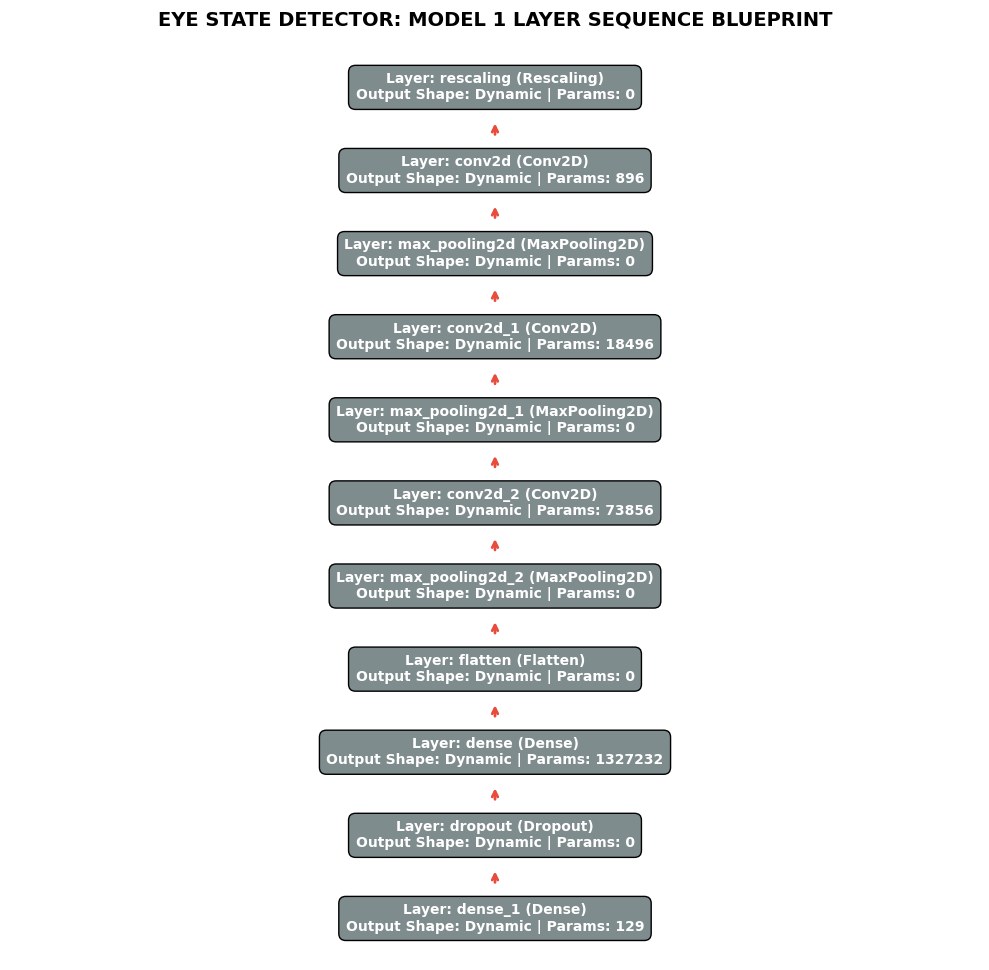

In [45]:
    # 15. Visual summary
    print("🎨 Drawing visual layer summary graph...")
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, len(model.layers) * 0.8 + 1))

    for idx, layer in enumerate(reversed(model.layers)):
        try:
            plot_shape = layer.output_shape
        except AttributeError:
            plot_shape = "Dynamic"

        ax.text(0.5, idx, f"Layer: {layer.name} ({layer.__class__.__name__})\nOutput Shape: {plot_shape} | Params: {layer.count_params()}",
                ha='center', va='center', color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50' if 'Conv' in layer.name or 'Dense' in layer.name else '#7f8c8d', edgecolor='black'))

        if idx < len(model.layers) - 1:
            ax.annotate('', xy=(0.5, idx + 0.4), xytext=(0.5, idx + 0.6),
                        arrowprops=dict(arrowstyle="<-", color='#e74c3c', lw=2))

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(model.layers) - 0.5)
    ax.axis('off')
    plt.title("EYE STATE DETECTOR: MODEL 1 LAYER SEQUENCE BLUEPRINT", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()

    img_buf = io.BytesIO()
    plt.savefig(img_buf, format='png', dpi=150, bbox_inches='tight')
    img_buf.seek(0)
    encoded_visual_chart = base64.b64encode(img_buf.read()).decode('utf-8')
    plt.show()
    plt.close()

In [46]:
# 16. Save to database
if model1_collection is not None:
    print("\n💾 Packaging blueprint payload and transmitting to MongoDB...")

    model1_document = {
        "timestamp": datetime.now(timezone.utc),
        "model_metadata": {
            "model_id": "model_1",
            "filename": "eye_state_detector.h5",
            "framework": "TensorFlow Keras Sequential"
        },
        "network_totals": {
            "total_layers": len(model.layers),
            "grand_total_parameters": int(model.count_params()),
            "total_individual_weights": int(total_weights_count),
            "total_individual_biases": int(total_biases_count)
        },
        "structural_blueprint_text": model_summary_text,
        "layer_by_layer_schema": layer_details,
        "visual_architecture_chart": encoded_visual_chart
    }

    try:
        write_receipt = model1_collection.insert_one(model1_document)
        print(f"🚀 Success! Architecture cataloged in cloud database. Record ID: {write_receipt.inserted_id}")
    except Exception as db_err:
        print(f"❌ Failed to push document schema out to MongoDB: {db_err}")
else:
    print("\n❌ Storage bypassed: Cloud instance reference was empty.")

gc.collect()


💾 Packaging blueprint payload and transmitting to MongoDB...
🚀 Success! Architecture cataloged in cloud database. Record ID: 6a1bcbb15ecc931c12d2f388


3218

In [47]:
# 17. Save model
model.save('eye_state_detector.h5')
print("\nModel saved successfully as eye_state_detector.h5")


Model saved successfully as eye_state_detector.h5
